In [1]:
#import kagglehub

# Download latest version
#path = kagglehub.dataset_download("shayanfazeli/heartbeat")

#print("Path to dataset files:", path)

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Conv1D, MaxPooling1D, Flatten,
    Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

print("TensorFlow version:", tf.__version__)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Environment ready ✓")

TensorFlow version: 2.21.0
Environment ready ✓


In [3]:
path = r"C:\Users\Muhammad\.cache\kagglehub\datasets\shayanfazeli\heartbeat\versions\1"

train_df = pd.read_csv(os.path.join(path, "mitbih_train.csv"), header=None)
test_df  = pd.read_csv(os.path.join(path, "mitbih_test.csv"), header=None)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


In [4]:
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values.astype(int)

X_test  = test_df.iloc[:, :-1].values
y_test  = test_df.iloc[:, -1].values.astype(int)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

X_train: (87554, 187)
y_train: (87554,)
X_test:  (21892, 187)
y_test:  (21892,)


In [6]:
class_labels = {
    0: "Normal",
    1: "Supraventricular",
    2: "Ventricular",
    3: "Fusion",
    4: "Unknown"
}

print("Classes:", class_labels)
print("\nTraining label distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls} ({class_labels[cls]}): {cnt:,} samples")

Classes: {0: 'Normal', 1: 'Supraventricular', 2: 'Ventricular', 3: 'Fusion', 4: 'Unknown'}

Training label distribution:
  Class 0 (Normal): 72,471 samples
  Class 1 (Supraventricular): 2,223 samples
  Class 2 (Ventricular): 5,788 samples
  Class 3 (Fusion): 641 samples
  Class 4 (Unknown): 6,431 samples


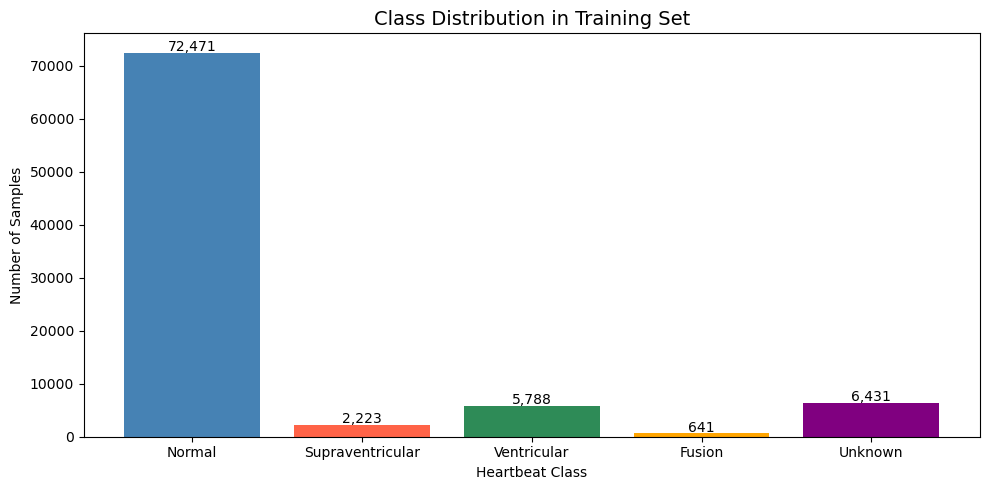

In [52]:
class_names = [class_labels[i] for i in range(5)]
counts = [np.sum(y_train == i) for i in range(5)]

plt.figure(figsize=(10, 5))
bars = plt.bar(class_names, counts, color=['steelblue','tomato','seagreen','orange','purple'])
plt.title("Class Distribution in Training Set", fontsize=14)
plt.xlabel("Heartbeat Class")
plt.ylabel("Number of Samples")

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'{count:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


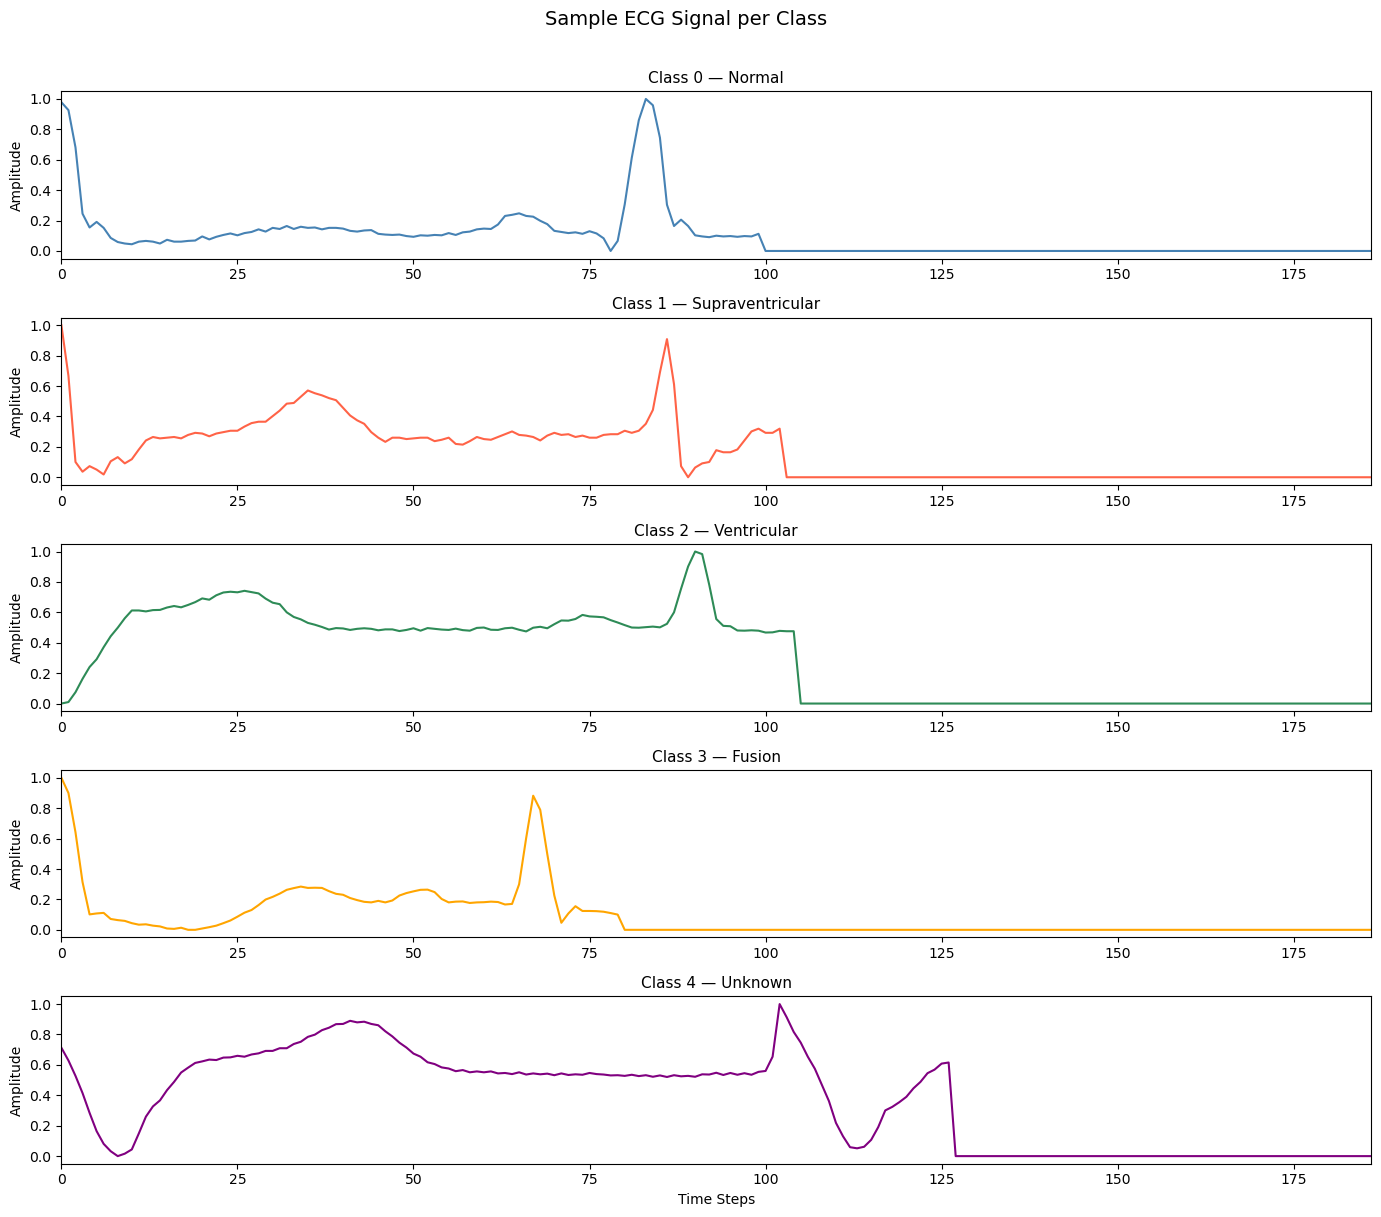

In [53]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12))

for i in range(5):
    sample = X_train[y_train == i][0]
    axes[i].plot(sample, color=['steelblue','tomato','seagreen','orange','purple'][i])
    axes[i].set_title(f"Class {i} — {class_labels[i]}", fontsize=11)
    axes[i].set_ylabel("Amplitude")
    axes[i].set_xlim(0, 186)

axes[-1].set_xlabel("Time Steps")
plt.suptitle("Sample ECG Signal per Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig2_sample_signals.png', dpi=150, bbox_inches='tight')
plt.show()

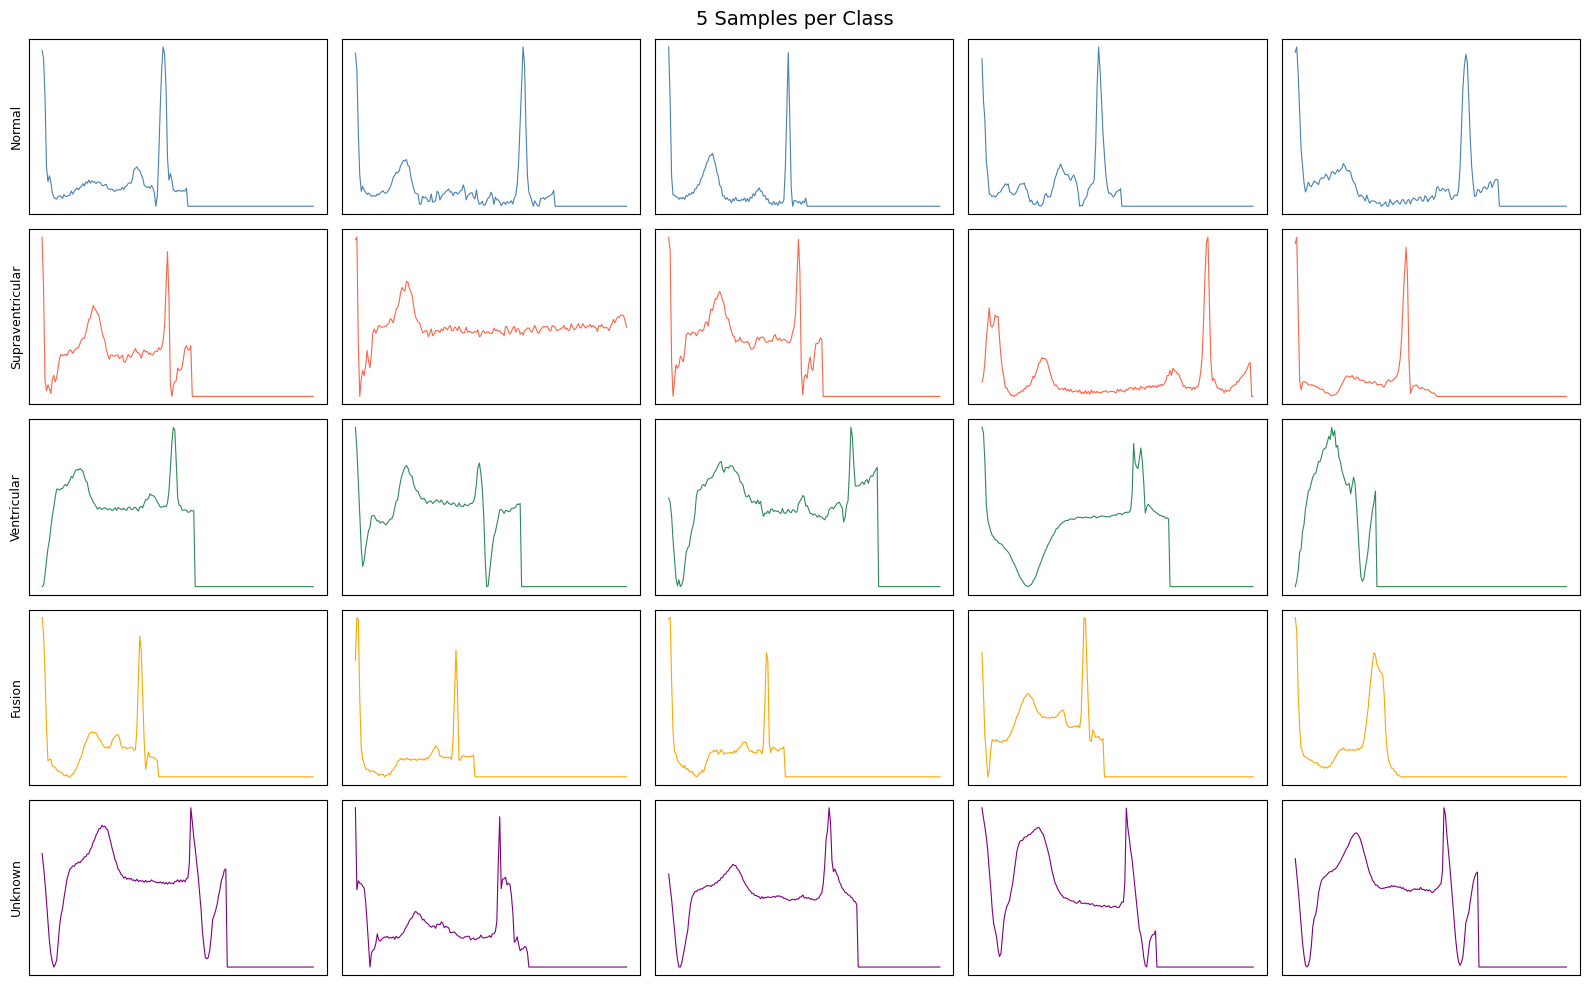

In [54]:
fig, axes = plt.subplots(5, 5, figsize=(16, 10))

for i in range(5):
    samples = X_train[y_train == i][:5]
    for j in range(5):
        axes[i][j].plot(samples[j], linewidth=0.8,
                        color=['steelblue','tomato','seagreen','orange','purple'][i])
        axes[i][j].set_xticks([])
        axes[i][j].set_yticks([])
        if j == 0:
            axes[i][j].set_ylabel(class_labels[i], fontsize=9)

plt.suptitle("5 Samples per Class", fontsize=14)
plt.tight_layout()
plt.savefig('fig3_multiple_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print(f"{'Class':<20} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 55)

for i in range(5):
    samples = X_train[y_train == i]
    print(f"{class_labels[i]:<20} {samples.mean():>8.4f} {samples.std():>8.4f} "
          f"{samples.min():>8.4f} {samples.max():>8.4f}")

Class                    Mean      Std      Min      Max
-------------------------------------------------------
Normal                 0.1619   0.2176   0.0000   1.0000
Supraventricular       0.1948   0.2146   0.0000   1.0000
Ventricular            0.2438   0.2623   0.0000   1.0000
Fusion                 0.1073   0.1930   0.0000   1.0000
Unknown                0.2509   0.2643   0.0000   1.0000


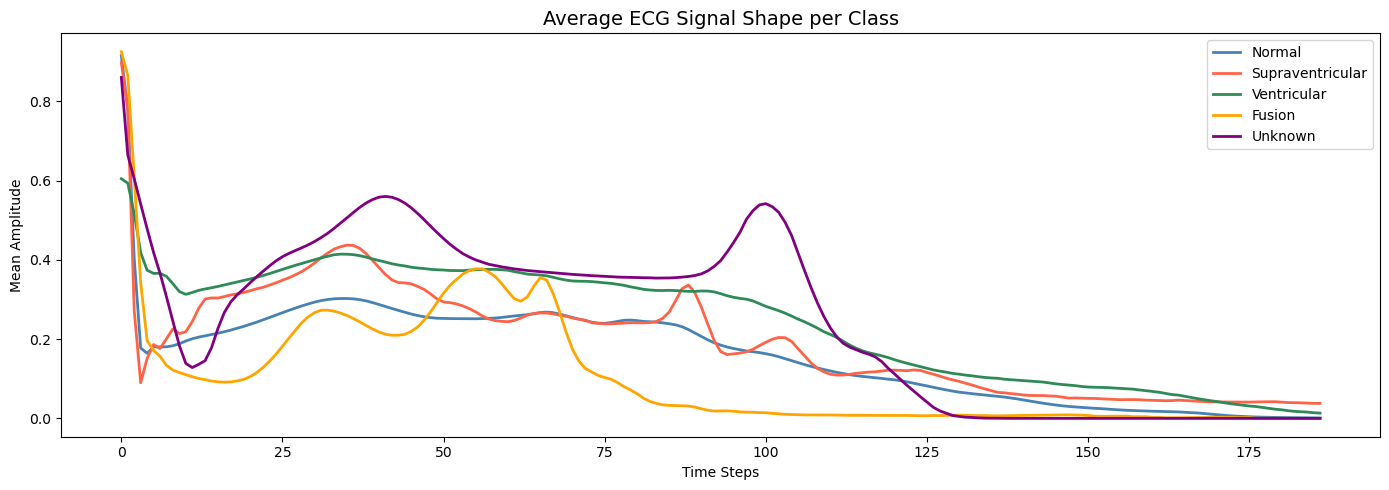

In [55]:
plt.figure(figsize=(14, 5))

colors = ['steelblue', 'tomato', 'seagreen', 'orange', 'purple']
for i in range(5):
    mean_signal = X_train[y_train == i].mean(axis=0)
    plt.plot(mean_signal, label=class_labels[i], color=colors[i], linewidth=2)

plt.title("Average ECG Signal Shape per Class", fontsize=14)
plt.xlabel("Time Steps")
plt.ylabel("Mean Amplitude")
plt.legend()
plt.tight_layout()
plt.savefig('fig4_average_signals.png', dpi=150, bbox_inches='tight')
plt.show()

# Data Preprocessing

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train — mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}")
print(f"Test  — mean: {X_test_scaled.mean():.4f}, std: {X_test_scaled.std():.4f}")

Train — mean: -0.0000, std: 1.0000
Test  — mean: -0.0048, std: 0.9946


In [ ]:
smote_enn = SMOTEENN(
    smote=SMOTE(
        sampling_strategy={
            1: 10000,   # Supraventricular — boost more
            2: 10000,   # Ventricular
            3: 8000,    # Fusion — was 5000, push harder
            4: 10000    # Unknown
        },
        k_neighbors=3,  # smaller = better for very rare classes like Fusion
        random_state=SEED
    ),
    random_state=SEED
)
X_train_balanced, y_train_balanced = smote_enn.fit_resample(X_train_scaled, y_train)

print("\nBefore:")
for i in range(5):
    print(f"  Class {i} ({class_labels[i]}): {np.sum(y_train == i):,}")

print("\nAfter:")
for i in range(5):
    print(f"  Class {i} ({class_labels[i]}): {np.sum(y_train_balanced == i):,}")

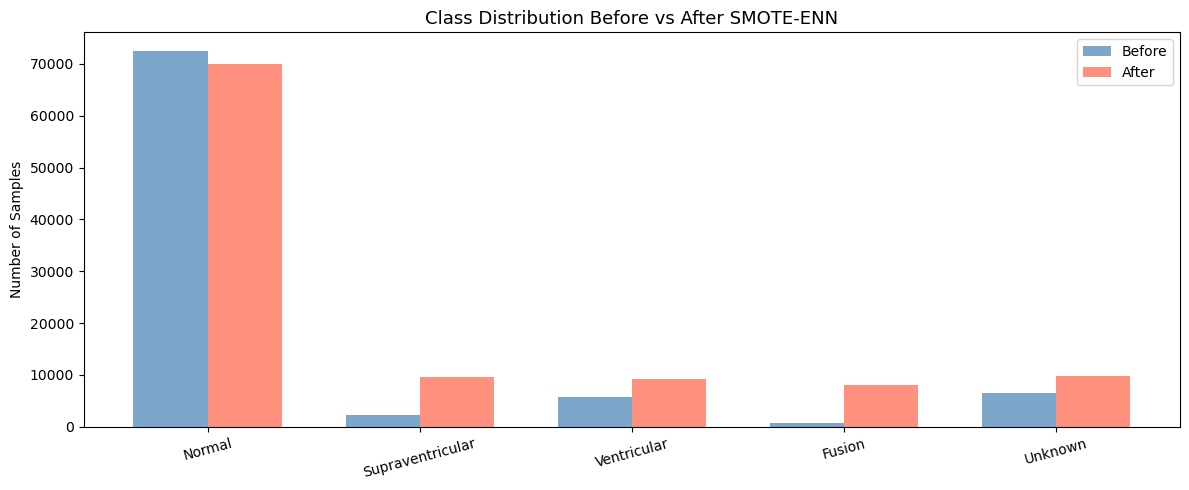

In [62]:
counts_before = [np.sum(y_train == i) for i in range(5)]
counts_after  = [np.sum(y_train_balanced == i) for i in range(5)]

x = np.arange(5)
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, counts_before, width, label='Before', color='steelblue', alpha=0.7)
plt.bar(x + width/2, counts_after,  width, label='After',  color='tomato',    alpha=0.7)
plt.xticks(x, list(class_labels.values()), rotation=15)
plt.title("Class Distribution Before vs After SMOTE-ENN", fontsize=13)
plt.ylabel("Number of Samples")
plt.legend()
plt.tight_layout()
plt.savefig('fig5_smoteenn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_balanced),
    y=y_train_balanced
)

class_weight_dict = dict(enumerate(class_weights_array))

print("Class weights after balancing:")
for cls, w in class_weight_dict.items():
    print(f"  Class {cls} ({class_labels[cls]}): {w:.4f}")

Class weights after balancing:
  Class 0 (Normal): 0.3045
  Class 1 (Supraventricular): 2.2164
  Class 2 (Ventricular): 2.3074
  Class 3 (Fusion): 2.6700
  Class 4 (Unknown): 2.1904


In [14]:
y_train_cat = to_categorical(y_train_balanced, num_classes=5)
y_test_cat  = to_categorical(y_test, num_classes=5)

X_train_cnn = X_train_balanced.reshape(X_train_balanced.shape[0], X_train_balanced.shape[1], 1)
X_test_cnn  = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print("Logistic / RF — X_train_balanced:", X_train_balanced.shape)
print("CNN           — X_train_cnn:     ", X_train_cnn.shape)
print("Test scaled   — X_test_scaled:   ", X_test_scaled.shape)
print("Labels (int)  — y_train_balanced:", y_train_balanced.shape)
print("Labels (cat)  — y_train_cat:     ", y_train_cat.shape)

Logistic / RF — X_train_balanced: (106453, 187)
CNN           — X_train_cnn:      (106453, 187, 1)
Test scaled   — X_test_scaled:    (21892, 187)
Labels (int)  — y_train_balanced: (106453,)
Labels (cat)  — y_train_cat:      (106453, 5)


# Logistic Regression 

In [19]:
print("Training Logistic Regression...")

log_reg = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=SEED
)

log_reg.fit(X_train_scaled, y_train)
print("Done ✓")

Training Logistic Regression...
Done ✓


In [20]:
y_pred_lr = log_reg.predict(X_test_scaled)

print("Logistic Regression — Test Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_lr)))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=list(class_labels.values())))

Logistic Regression — Test Accuracy: 0.6744

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.97      0.65      0.78     18118
Supraventricular       0.15      0.66      0.24       556
     Ventricular       0.30      0.73      0.42      1448
          Fusion       0.08      0.87      0.15       162
         Unknown       0.72      0.91      0.81      1608

        accuracy                           0.67     21892
       macro avg       0.44      0.76      0.48     21892
    weighted avg       0.88      0.67      0.74     21892



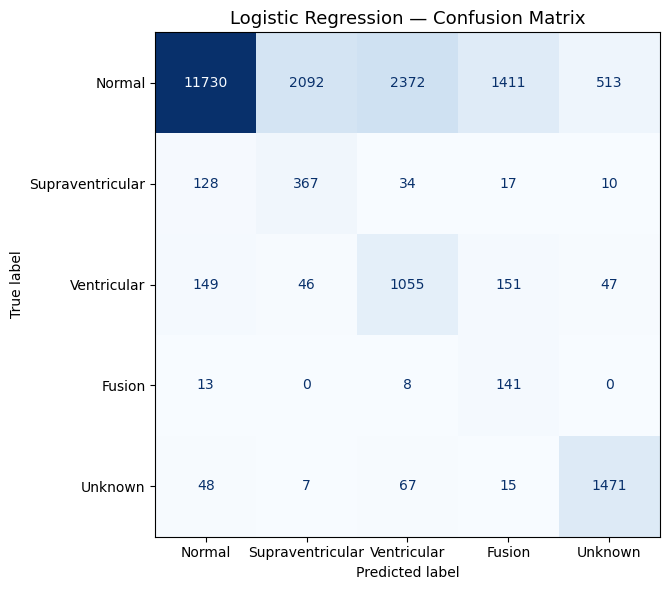

In [21]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=list(class_labels.values()))
disp.plot(cmap='Blues', ax=plt.gca(), colorbar=False)
plt.title("Logistic Regression — Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.show()

# Random Forest

In [22]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
print("Done ✓")

Training Random Forest...
Done ✓


In [23]:
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest — Test Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_rf)))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=list(class_labels.values())))

Random Forest — Test Accuracy: 0.9723

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.97      0.99      0.98     18118
Supraventricular       0.92      0.63      0.75       556
     Ventricular       0.98      0.88      0.93      1448
          Fusion       0.58      0.68      0.63       162
         Unknown       1.00      0.95      0.97      1608

        accuracy                           0.97     21892
       macro avg       0.89      0.83      0.85     21892
    weighted avg       0.97      0.97      0.97     21892



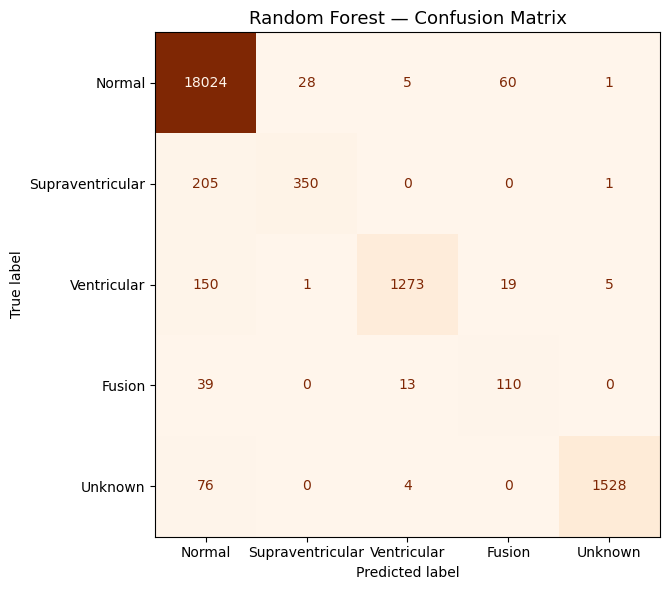

In [24]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=list(class_labels.values()))
disp.plot(cmap='Oranges', ax=plt.gca(), colorbar=False)
plt.title("Random Forest — Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.show()

# CNN 

In [40]:
from tensorflow.keras.regularizers import l2

cnn_model = Sequential([
    Conv1D(64,  kernel_size=5, activation='relu', input_shape=(187, 1),
           kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(128, kernel_size=3, activation='relu',
           kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(256, kernel_size=3, activation='relu',
           kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling1D(2),

    Flatten(),

    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.4),

    Dense(5, activation='softmax')
])

In [41]:
import tensorflow as tf

def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * y_true * tf.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * ce, axis=1))
    return loss_fn

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

In [42]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history_cnn = cnn_model.fit(
    X_train_cnn, y_train_cat,
    epochs=8,
    batch_size=64,
    validation_data=(X_test_cnn, y_test_cat),  # ← real data for validation
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("Done ✓")

Epoch 1/8
1664/1664 ━━━━━━━━━━━━━━━━━━━━ 138s 81ms/step - accuracy: 0.8706 - loss: 0.2245 - val_accuracy: 0.9560 - val_loss: 0.0762 - learning_rate: 0.0010
Epoch 2/8
1664/1664 ━━━━━━━━━━━━━━━━━━━━ 127s 77ms/step - accuracy: 0.9273 - loss: 0.0657 - val_accuracy: 0.9396 - val_loss: 0.0655 - learning_rate: 0.0010
Epoch 3/8
1664/1664 ━━━━━━━━━━━━━━━━━━━━ 133s 80ms/step - accuracy: 0.9361 - loss: 0.0540 - val_accuracy: 0.9603 - val_loss: 0.0498 - learning_rate: 0.0010
Epoch 4/8
1664/1664 ━━━━━━━━━━━━━━━━━━━━ 128s 77ms/step - accuracy: 0.9427 - loss: 0.0458 - val_accuracy: 0.9604 - val_loss: 0.0435 - learning_rate: 0.0010
Epoch 5/8
1664/1664 ━━━━━━━━━━━━━━━━━━━━ 130s 78ms/step - accuracy: 0.9473 - loss: 0.0404 - val_accuracy: 0.9684 - val_loss: 0.0368 - learning_rate: 0.0010
Epoch 6/8
1664/1664 ━━━━━━━━━━━━━━━━━━━━ 130s 78ms/step - accuracy: 0.9499 - loss: 0.0373 - val_accuracy: 0.9637 - val_loss: 0.0374 - learning_rate: 0.0010
Epoch 7/8
1664/1664 ━━━━━━━━━━━━━━━━━━━━ 154s 85ms/step - accura

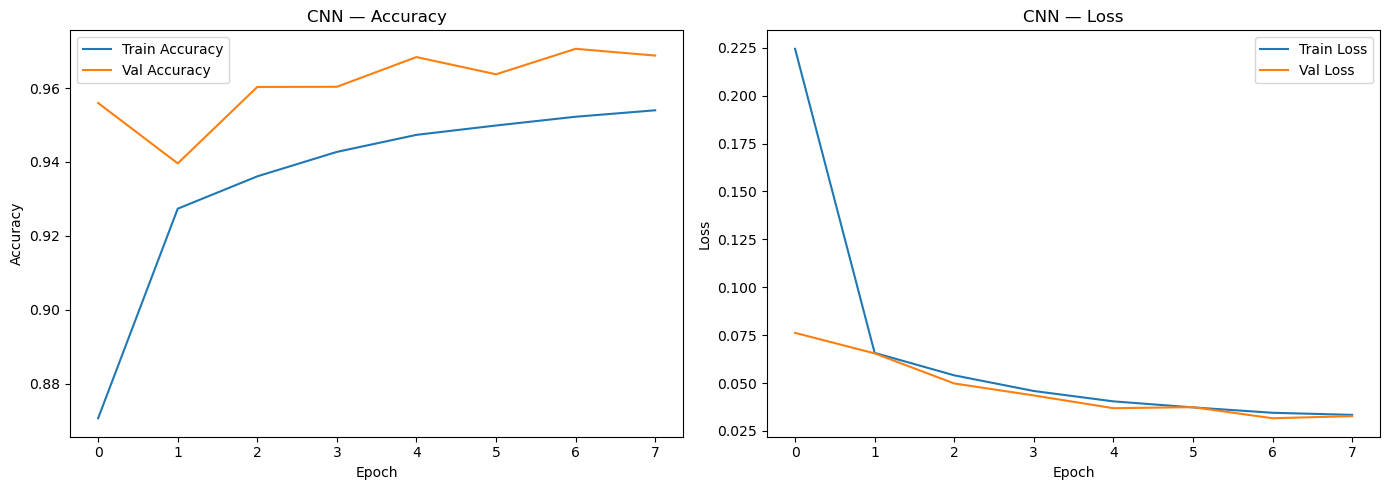

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_cnn.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history_cnn.history['val_accuracy'],  label='Val Accuracy')
axes[0].set_title("CNN — Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history_cnn.history['loss'],     label='Train Loss')
axes[1].plot(history_cnn.history['val_loss'], label='Val Loss')
axes[1].set_title("CNN — Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig('fig10_cnn_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [44]:
y_pred_cnn_probs = cnn_model.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)

print("CNN — Test Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_cnn)))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cnn, target_names=list(class_labels.values())))

685/685 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step
CNN — Test Accuracy: 0.9706

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.98      0.99      0.98     18118
Supraventricular       0.80      0.69      0.74       556
     Ventricular       0.97      0.86      0.91      1448
          Fusion       0.58      0.86      0.69       162
         Unknown       0.99      0.95      0.97      1608

        accuracy                           0.97     21892
       macro avg       0.86      0.87      0.86     21892
    weighted avg       0.97      0.97      0.97     21892



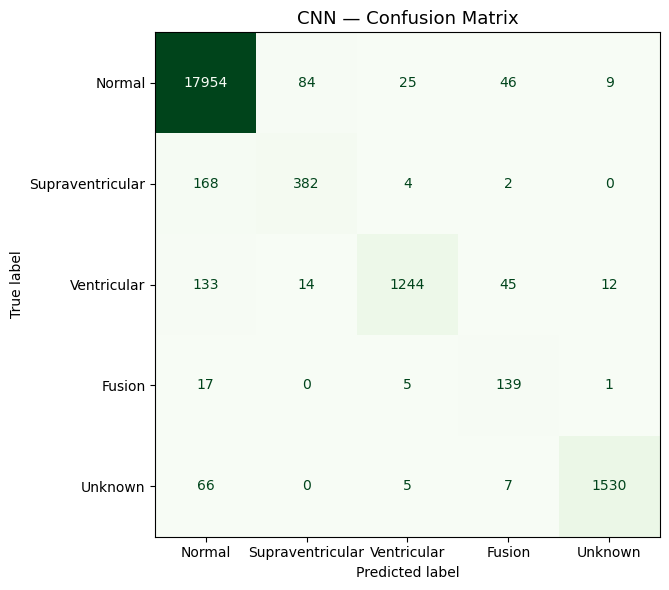

In [45]:
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=list(class_labels.values()))
disp.plot(cmap='Greens', ax=plt.gca(), colorbar=False)
plt.title("CNN — Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.show()

# svm

In [15]:
from sklearn.svm import SVC

print("Training SVM (this may take 5–10 minutes)...")

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    random_state=SEED
)

svm_model.fit(X_train_balanced, y_train_balanced)
print("Done ✓")


Training SVM (this may take 5–10 minutes)...
Done ✓


In [16]:
y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM — Test Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_svm)))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=list(class_labels.values())))

SVM — Test Accuracy: 0.9557

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.99      0.96      0.98     18118
Supraventricular       0.51      0.78      0.62       556
     Ventricular       0.94      0.92      0.93      1448
          Fusion       0.40      0.87      0.55       162
         Unknown       0.98      0.97      0.98      1608

        accuracy                           0.96     21892
       macro avg       0.76      0.90      0.81     21892
    weighted avg       0.97      0.96      0.96     21892



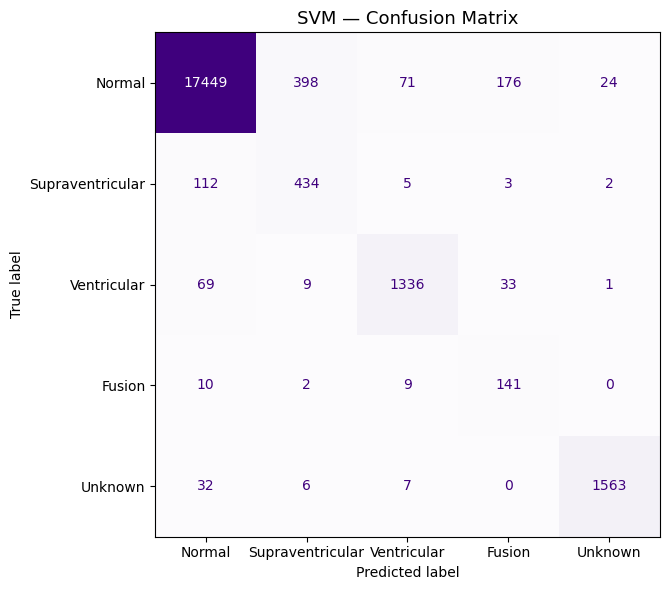

In [17]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=list(class_labels.values()))
disp.plot(cmap='Purples', ax=plt.gca(), colorbar=False)
plt.title("SVM — Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.show()

# Evaluation & Comparison

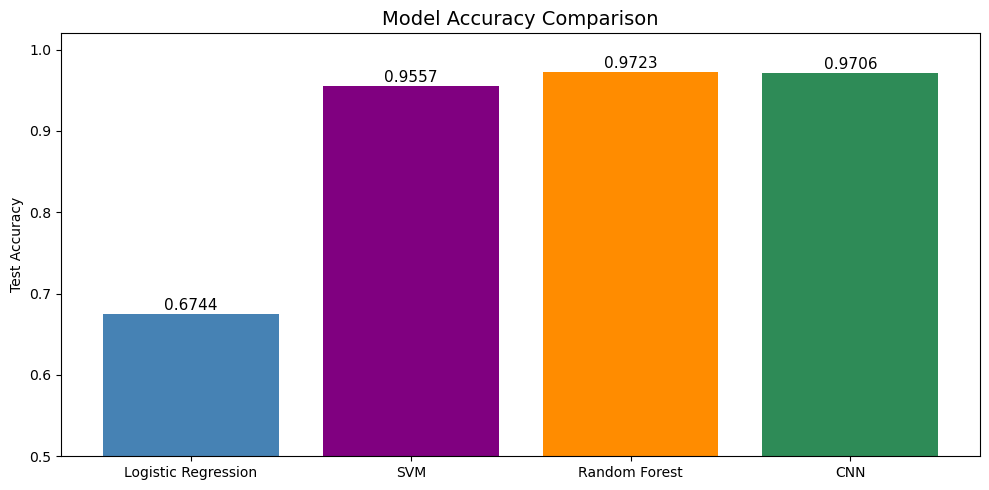

In [57]:
models = ['Logistic Regression', 'SVM', 'Random Forest', 'CNN']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_cnn)
]

plt.figure(figsize=(10, 5))
bars = plt.bar(models, accuracies, color=['steelblue', 'purple', 'darkorange', 'seagreen'])
plt.ylim(0.5, 1.02)
plt.title("Model Accuracy Comparison", fontsize=14)
plt.ylabel("Test Accuracy")

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('fig6_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

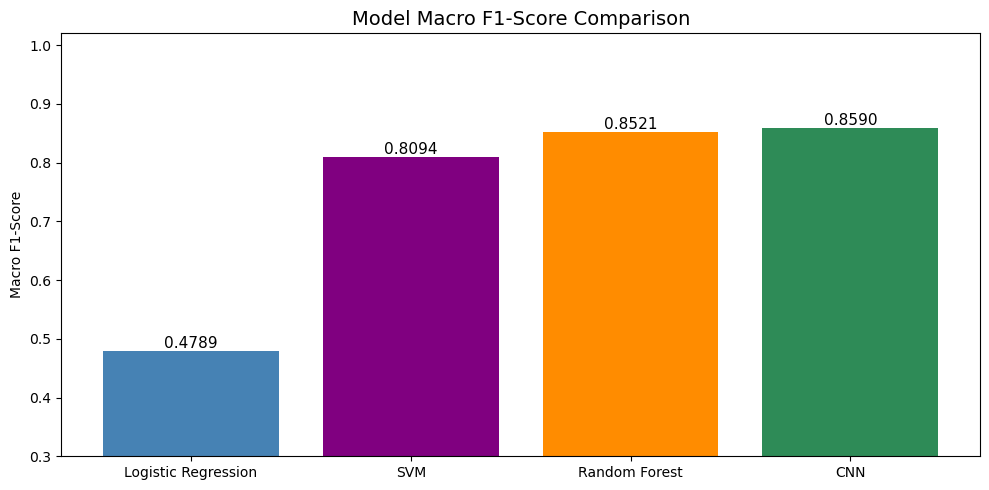

In [58]:
from sklearn.metrics import f1_score

macro_f1s = [
    f1_score(y_test, y_pred_lr,  average='macro'),
    f1_score(y_test, y_pred_svm, average='macro'),
    f1_score(y_test, y_pred_rf,  average='macro'),
    f1_score(y_test, y_pred_cnn, average='macro')
]

plt.figure(figsize=(10, 5))
bars = plt.bar(models, macro_f1s, color=['steelblue', 'purple', 'darkorange', 'seagreen'])
plt.ylim(0.3, 1.02)
plt.title("Model Macro F1-Score Comparison", fontsize=14)
plt.ylabel("Macro F1-Score")

for bar, f1 in zip(bars, macro_f1s):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{f1:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('fig7_macrof1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

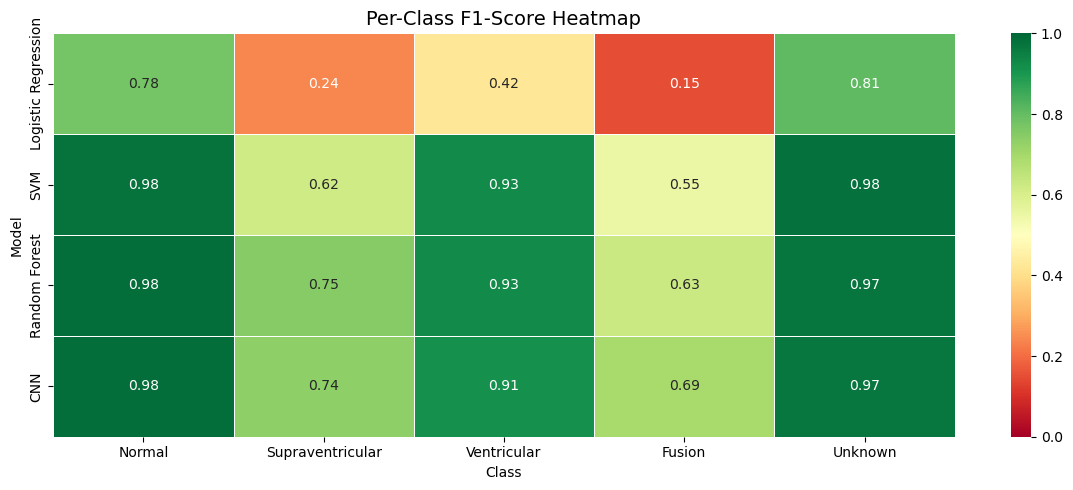

In [59]:
from sklearn.metrics import classification_report
import pandas as pd

reports = {}
preds = {
    'Logistic Regression': y_pred_lr,
    'SVM':                 y_pred_svm,
    'Random Forest':       y_pred_rf,
    'CNN':                 y_pred_cnn
}

for name, pred in preds.items():
    report = classification_report(y_test, pred,
                                   target_names=list(class_labels.values()),
                                   output_dict=True)
    reports[name] = {cls: report[cls]['f1-score'] for cls in class_labels.values()}

f1_df = pd.DataFrame(reports).T

plt.figure(figsize=(12, 5))
sns.heatmap(f1_df, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5)
plt.title("Per-Class F1-Score Heatmap", fontsize=14)
plt.ylabel("Model")
plt.xlabel("Class")
plt.tight_layout()
plt.savefig('fig8_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

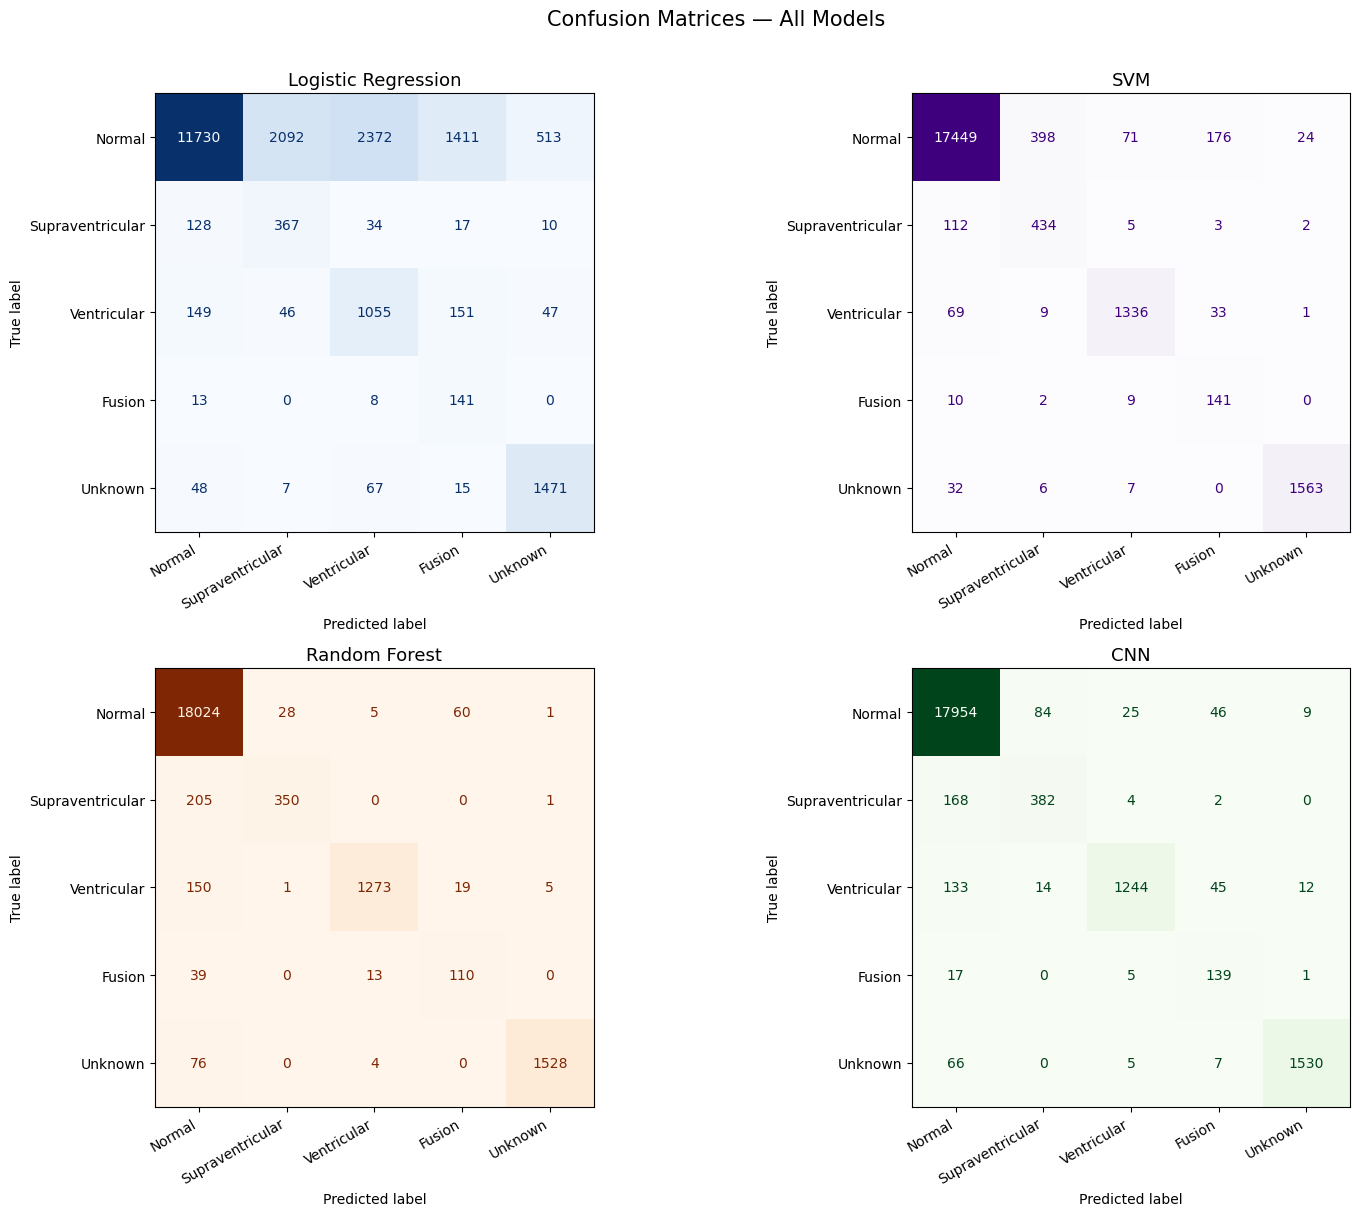

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

cms = [cm_lr, cm_svm, cm_rf, cm_cnn]
titles = ['Logistic Regression', 'SVM', 'Random Forest', 'CNN']
cmaps = ['Blues', 'Purples', 'Oranges', 'Greens']

for ax, cm, title, cmap in zip(axes.flatten(), cms, titles, cmaps):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=list(class_labels.values()))
    disp.plot(cmap=cmap, ax=ax, colorbar=False)
    ax.set_title(title, fontsize=13)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.suptitle("Confusion Matrices — All Models", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('fig9_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [50]:
summary = pd.DataFrame({
    'Model':    models,
    'Accuracy': [f'{a:.4f}' for a in accuracies],
    'Macro F1': [f'{f:.4f}' for f in macro_f1s]
})

summary = summary.sort_values('Macro F1', ascending=False).reset_index(drop=True)
print("=" * 45)
print("FINAL MODEL COMPARISON")
print("=" * 45)
print(summary.to_string(index=False))
print("=" * 45)

FINAL MODEL COMPARISON
              Model Accuracy Macro F1
                CNN   0.9706   0.8590
      Random Forest   0.9723   0.8521
                SVM   0.9557   0.8094
Logistic Regression   0.6744   0.4789
